In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from matplotlib.lines import Line2D
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

from style import set_style, lr_labels
set_style()

PLOT_DIR = Path('plots/kappaScan')
PLOT_DIR.mkdir(parents=True, exist_ok=True)
print(f"Plots will be saved to: {PLOT_DIR.resolve()}")

Plots will be saved to: /Users/sambt/iaifi/sv3/analysis/plots/kappaScan


In [2]:
# Load results
from style import load_results

SCAN_CONFIGS = {
    'MNIST':    'mnist_kappaScan_labelRegression',
    'Toy 1D':              'toy_1d_kappaScan',
    'Polynomial':          'polynomial_kappaScan',
}

datasets = {}
for name, scan_name in SCAN_CONFIGS.items():
    try:
        df = load_results(scan_name)
        datasets[name] = df
    except FileNotFoundError:
        print(f"  [skip] {name}: not found")

print(f"\nLoaded {len(datasets)} datasets: {list(datasets.keys())}")


Loaded 50 runs from ../experiment_results/mnist_kappaScan_labelRegression/ (directory format)
Loaded 70 runs from ../experiment_results/toy_1d_kappaScan/ (directory format)
Loaded 190 runs from ../experiment_results/polynomial_kappaScan/ (directory format)

Loaded 3 datasets: ['MNIST', 'Toy 1D', 'Polynomial']


In [3]:
# Helper functions
def get_loss_curve(row, loss_type='val'):
    return np.array(row['losses'][loss_type])

def get_acc_curve(row, acc_type='val_acc'):
    return np.array(row['losses'].get(acc_type, []))

def sliding_average(data, window=10):
    return np.convolve(data, np.ones(window)/window, mode='valid')

def add_derived_columns(df):
    df = df.copy()
    df['final_val_loss'] = df.apply(lambda r: r['losses']['val'][-1], axis=1)
    df['final_train_loss'] = df.apply(lambda r: r['losses']['train'][-1], axis=1)
    df['final_val_acc'] = df.apply(lambda r: r['losses'].get('val_acc', [np.nan])[-1], axis=1)
    df['final_train_acc'] = df.apply(lambda r: r['losses'].get('train_acc', [np.nan])[-1], axis=1)
    df['total_time'] = df['losses'].apply(lambda l: l.get('total_time', np.nan))
    df['avg_batch_time_train'] = df['losses'].apply(lambda l: l.get('avg_batch_time_train', np.nan))
    # Ensure param_fraction is numeric
    df['param_fraction'] = df['param_fraction'].fillna(1.0).astype(float)
    return df

for name in datasets:
    datasets[name] = add_derived_columns(datasets[name])

for name, df in datasets.items():
    print(f"{name}: {len(df)} runs")

MNIST: 50 runs
Toy 1D: 70 runs
Polynomial: 190 runs


In [4]:
kappas_1d = sorted(datasets['Toy 1D']['kappa'].unique().tolist())
model_seeds_1d = datasets['Toy 1D']['model_seed'].unique()
k_values_1d = datasets['Toy 1D']['k'].unique()
rtols_1d = datasets['Toy 1D']['rtol'].unique()
lrs_1d = datasets['Toy 1D']['lr'].unique()
print(f"Toy 1D kappas: {kappas_1d}")
print(f"Toy 1D model_seeds: {model_seeds_1d}")
print(f"Toy 1D k_values: {k_values_1d}")
print(f"Toy 1D learning rates: {lrs_1d}")
print(f"Toy 1D rtols: {rtols_1d}")

print("="*50)

kappas_polynomial = sorted(datasets['Polynomial']['kappa'].unique().tolist())
model_seeds_polynomial = datasets['Polynomial']['model_seed'].unique()
k_values_polynomial = datasets['Polynomial']['k'].unique()
rtols_polynomial = datasets['Polynomial']['rtol'].unique()
lrs_polynomial = datasets['Polynomial']['lr'].unique()
print(f"Polynomial kappas: {kappas_polynomial}")
print(f"Polynomial model_seeds: {model_seeds_polynomial}")
print(f"Polynomial k_values: {k_values_polynomial}")
print(f"Polynomial learning rates: {lrs_polynomial}")
print(f"Polynomial rtols: {rtols_polynomial}")

print("="*50)

kappas_mnist = sorted(datasets['MNIST']['kappa'].unique().tolist())
model_seeds_mnist = datasets['MNIST']['model_seed'].unique()
k_values_mnist = datasets['MNIST']['k'].unique()
rtols_mnist = datasets['MNIST']['rtol'].unique()
lrs_mnist = datasets['MNIST']['lr'].unique()
print(f"MNIST kappas: {kappas_mnist}")
print(f"MNIST model_seeds: {model_seeds_mnist}")
print(f"MNIST k_values: {k_values_mnist}")
print(f"MNIST learning rates: {lrs_mnist}")
print(f"MNIST rtols: {rtols_mnist}")

Toy 1D kappas: [1.0, 1.5, 2.0, 2.5, 3.0]
Toy 1D model_seeds: [4310 4311 4312 4313 4314 4315 4316 4317 4318 4319]
Toy 1D k_values: [32]
Toy 1D learning rates: [0.05 0.1 ]
Toy 1D rtols: [0.001]
Polynomial kappas: [1.0, 1.5, 2.0, 2.5, 3.0]
Polynomial model_seeds: [5310 5311 5312 5313 5314 5315 5316 5317 5318 5319]
Polynomial k_values: [32]
Polynomial learning rates: [0.1 0.5]
Polynomial rtols: [0.001 0.01 ]
MNIST kappas: [1.0, 1.5, 2.0, 2.5, 3.0]
MNIST model_seeds: [6310 6311 6312 6313 6314 6315 6316 6317 6318 6319]
MNIST k_values: [64]
MNIST learning rates: [0.5]
MNIST rtols: [0.0001]


# 1D Regression

bad run with kappa = 1.0, model_seed = 4310, k = 32, rtol = 0.001, lr = 0.05: found 0 runs
bad run with kappa = 1.0, model_seed = 4311, k = 32, rtol = 0.001, lr = 0.05: found 0 runs
bad run with kappa = 1.0, model_seed = 4312, k = 32, rtol = 0.001, lr = 0.05: found 0 runs
bad run with kappa = 1.0, model_seed = 4313, k = 32, rtol = 0.001, lr = 0.05: found 0 runs
bad run with kappa = 1.0, model_seed = 4314, k = 32, rtol = 0.001, lr = 0.05: found 0 runs
bad run with kappa = 1.0, model_seed = 4315, k = 32, rtol = 0.001, lr = 0.05: found 0 runs
bad run with kappa = 1.0, model_seed = 4317, k = 32, rtol = 0.001, lr = 0.05: found 0 runs
bad run with kappa = 1.0, model_seed = 4318, k = 32, rtol = 0.001, lr = 0.05: found 0 runs
bad run with kappa = 1.0, model_seed = 4319, k = 32, rtol = 0.001, lr = 0.05: found 0 runs
bad run with kappa = 1.5, model_seed = 4310, k = 32, rtol = 0.001, lr = 0.05: found 0 runs
bad run with kappa = 1.5, model_seed = 4311, k = 32, rtol = 0.001, lr = 0.05: found 0 runs

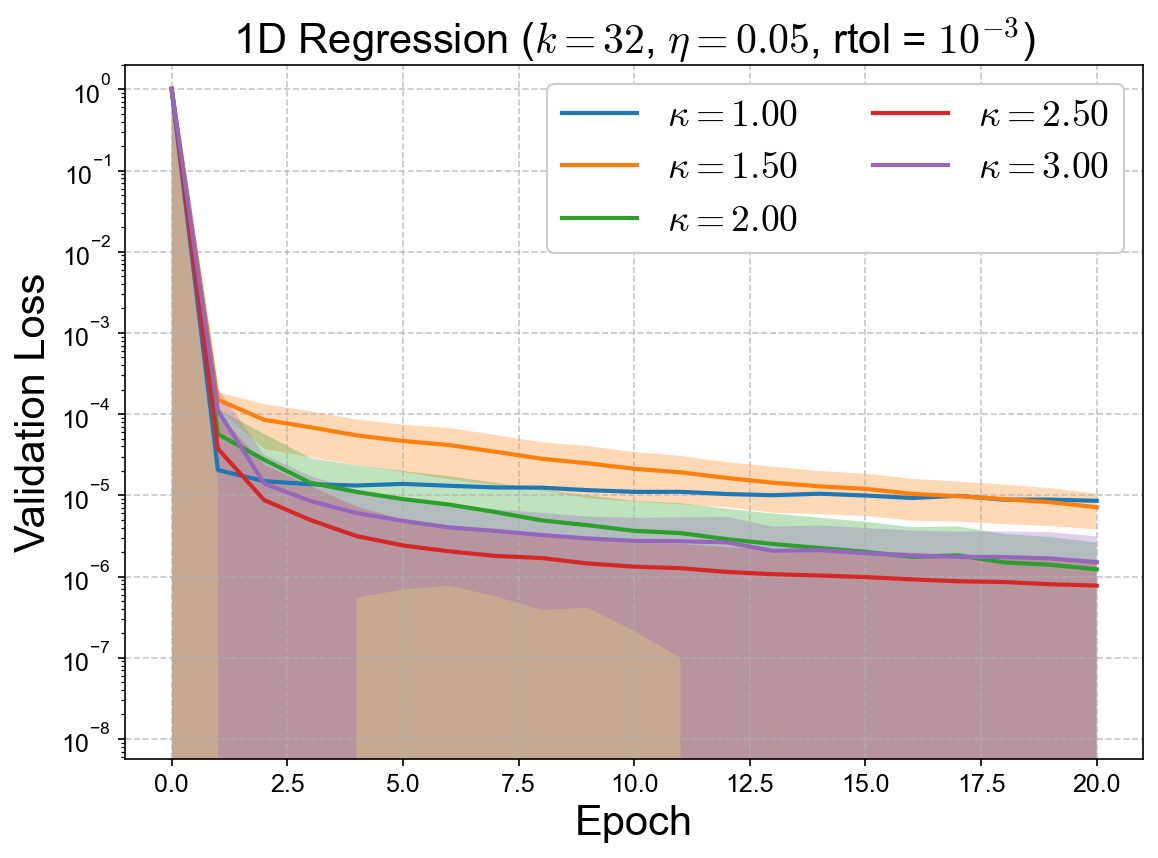

In [8]:
colors = sns.color_palette("deep")

fig, ax = plt.subplots(figsize=(8, 6))

K_SEL = 32
RTOL = 1e-3
LR = 0.05

df = datasets['Toy 1D']

for kappa in kappas_1d:
    losses = []
    for mseed in model_seeds_1d:
        cut = (df['kappa'] == kappa) & (df['model_seed'] == mseed) & (df['k'] == K_SEL) & (df['rtol'] == RTOL) & (df['lr'] == LR)
        row = df.loc[cut]
        if len(row) > 1 or len(row) == 0:
            print(f"bad run with kappa = {kappa}, model_seed = {mseed}, k = {K_SEL}, rtol = {RTOL}, lr = {LR}: found {len(row)} runs")
            continue
        row = row.iloc[0]
        losses.append(np.array(get_loss_curve(row, 'val')).reshape(1,-1))
    if not losses:
        continue
    losses = np.concatenate(losses, axis=0)
    mean_loss = np.mean(losses, axis=0)
    std_loss = np.std(losses, axis=0)
    epochs = np.arange(len(mean_loss))
    ax.plot(epochs, mean_loss, label=f"$\\kappa={kappa:.2f}$", zorder=2)
    ax.fill_between(epochs, mean_loss - std_loss, mean_loss + std_loss, alpha=0.3, zorder=1)

ax.set_xlabel('Epoch')
ax.set_ylabel('Validation Loss')
ax.set_yscale('log')
plt.legend(ncol=2,loc='upper right',frameon=True,framealpha=1, fontsize=18)
ax.set_title(f"1D Regression ($k = {K_SEL}$, $\\eta = {LR}$, rtol = ${lr_labels[RTOL]}$)")
plt.ylim([None,2])
plt.grid(axis='both', linestyle='--', alpha=0.7, zorder=0)
plt.tight_layout()
plt.savefig(PLOT_DIR / "toy_1d_val_loss_kappaScan.pdf",bbox_inches='tight')

# Polynomial Regression

bad run with kappa = 1.0, model_seed = 5317, k = 32, rtol = 0.01, lr = 0.1: found 0 runs
bad run with kappa = 1.0, model_seed = 5319, k = 32, rtol = 0.01, lr = 0.1: found 0 runs
bad run with kappa = 1.5, model_seed = 5310, k = 32, rtol = 0.01, lr = 0.1: found 0 runs
bad run with kappa = 1.5, model_seed = 5314, k = 32, rtol = 0.01, lr = 0.1: found 0 runs
bad run with kappa = 1.5, model_seed = 5315, k = 32, rtol = 0.01, lr = 0.1: found 0 runs


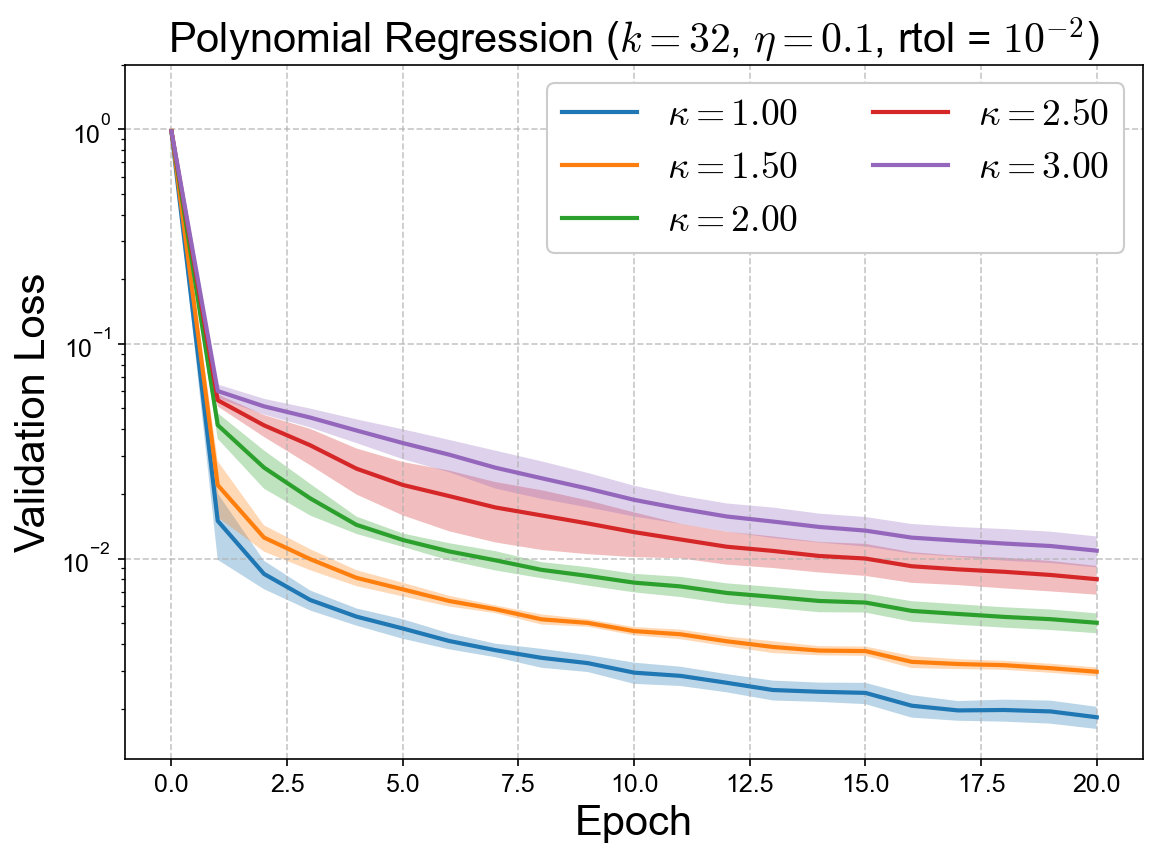

In [9]:
colors = sns.color_palette("deep")

fig, ax = plt.subplots(figsize=(8, 6))

K_SEL = 32
RTOL = 1e-2
LR = 0.1

df = datasets['Polynomial']

for kappa in kappas_polynomial:
    losses = []
    for mseed in model_seeds_polynomial:
        cut = (df['kappa'] == kappa) & (df['model_seed'] == mseed) & (df['k'] == K_SEL) & (df['rtol'] == RTOL) & (df['lr'] == LR)
        row = df.loc[cut]
        if len(row) > 1 or len(row) == 0:
            print(f"bad run with kappa = {kappa}, model_seed = {mseed}, k = {K_SEL}, rtol = {RTOL}, lr = {LR}: found {len(row)} runs")
            continue
        row = row.iloc[0]
        losses.append(np.array(get_loss_curve(row, 'val')).reshape(1,-1))
    if len(losses) == 0:
        print(f"No valid runs found for kappa = {kappa}, skipping...")
        continue
    losses = np.concatenate(losses, axis=0)
    mean_loss = np.mean(losses, axis=0)
    std_loss = np.std(losses, axis=0)
    epochs = np.arange(len(mean_loss))
    ax.plot(epochs, mean_loss, label=f"$\\kappa={kappa:.2f}$", zorder=2)
    ax.fill_between(epochs, mean_loss - std_loss, mean_loss + std_loss, alpha=0.3, zorder=1)

ax.set_xlabel('Epoch')
ax.set_ylabel('Validation Loss')
ax.set_yscale('log')
plt.legend(ncol=2,loc='upper right',frameon=True,framealpha=1, fontsize=18)
ax.set_title(f"Polynomial Regression ($k = {K_SEL}$, $\\eta = {LR}$, rtol = ${lr_labels[RTOL]}$)")
plt.ylim([None,2])
plt.grid(axis='both', linestyle='--', alpha=0.7, zorder=0)
plt.tight_layout()
plt.savefig(PLOT_DIR / "polynomial_val_loss_kappaScan.pdf",bbox_inches='tight')

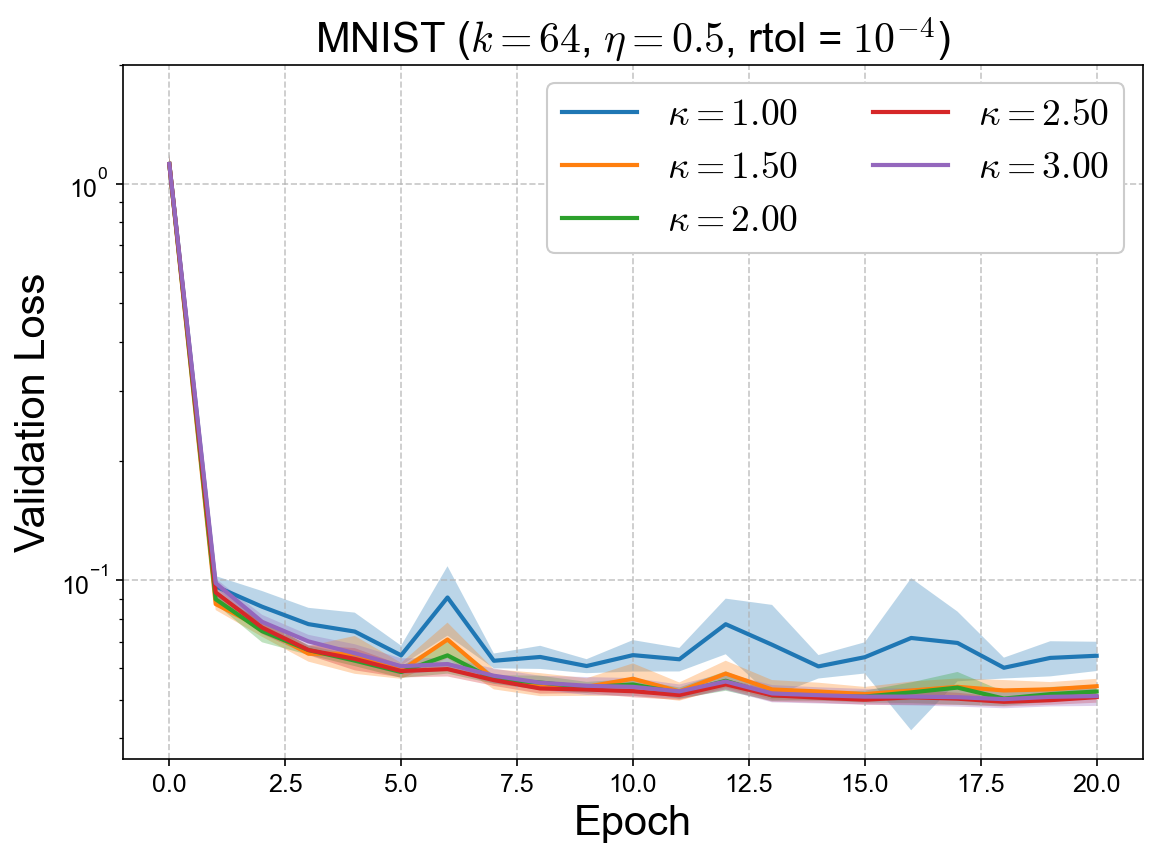

In [10]:
colors = sns.color_palette("deep")

fig, ax = plt.subplots(figsize=(8, 6))

K_SEL = 64
RTOL = 1e-4
LR = 0.5

df = datasets['MNIST']

for kappa in kappas_mnist:
    losses = []
    for mseed in model_seeds_mnist:
        cut = (df['kappa'] == kappa) & (df['model_seed'] == mseed) & (df['k'] == K_SEL) & (df['rtol'] == RTOL) & (df['lr'] == LR)
        row = df.loc[cut]
        if len(row) > 1 or len(row) == 0:
            print(f"bad run with kappa = {kappa}, model_seed = {mseed}, k = {K_SEL}, rtol = {RTOL}, lr = {LR}: found {len(row)} runs")
            continue
        row = row.iloc[0]
        losses.append(np.array(get_loss_curve(row, 'val')).reshape(1,-1))
    if len(losses) == 0:
        print(f"No valid runs found for kappa = {kappa}, skipping...")
        continue
    losses = np.concatenate(losses, axis=0)
    mean_loss = np.mean(losses, axis=0)
    std_loss = np.std(losses, axis=0)
    epochs = np.arange(len(mean_loss))
    ax.plot(epochs, mean_loss, label=f"$\\kappa={kappa:.2f}$", zorder=2)
    ax.fill_between(epochs, mean_loss - std_loss, mean_loss + std_loss, alpha=0.3, zorder=1)

ax.set_xlabel('Epoch')
ax.set_ylabel('Validation Loss')
ax.set_yscale('log')
plt.legend(ncol=2,loc='upper right',frameon=True,framealpha=1, fontsize=18)
ax.set_title(f"MNIST ($k = {K_SEL}$, $\\eta = {LR}$, rtol = ${lr_labels[RTOL]}$)")
plt.ylim([None,2])
plt.grid(axis='both', linestyle='--', alpha=0.7, zorder=0)
plt.tight_layout()
plt.savefig(PLOT_DIR / "mnist_val_loss_kappaScan.pdf",bbox_inches='tight')